# Shared Memory Parallelism with OpenMP

During this exercise we will parallelize the stencil program from day 1 using OpenMP. The goal is to apply the OpenMP concepts that have been discussed in the lecture. If everything goes well, at the end of this exercise you will have a parallel version of the diffusion operator.

So let's start!

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "72"
os.environ["OMP_PROC_BIND"] = "close"
os.environ["OMP_PLACES"] = "cores"

## Performance Baseline

In the first step we will see how fast our code runs and what the straightforward insertion of OpenMP directives can do.

In [2]:
import timeit

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

We start by compiling the Fortran stencil2d base code (this is the code with inlining you have worked on previously).

In [3]:
%%bash
make clean

rm -f -rf *~ *.o *.mod *.MOD *.i core.* *.out *.lst *.x *.x+orig *.x+[0-9]* *.dat *.report result_*.py report*.txt perf/* out*.txt


In [4]:
%%bash
make clean
make VERSION=base

rm -f -rf *~ *.o *.mod *.MOD *.i core.* *.out *.lst *.x *.x+orig *.x+[0-9]* *.dat *.report result_*.py report*.txt perf/* out*.txt
mpif90 -ffree-line-length-none  -g1 -O3 -fno-inline -fno-optimize-sibling-calls -fno-omit-frame-pointer -march=native -funroll-loops -fopenmp -flto -fno-math-errno -c m_utils.F90
mpif90 -ffree-line-length-none  -g1 -O3 -fno-inline -fno-optimize-sibling-calls -fno-omit-frame-pointer -march=native -funroll-loops -fopenmp -flto -fno-math-errno -c stencil2d-base.F90
mpif90 -ffree-line-length-none  -g1 -O3 -fno-inline -fno-optimize-sibling-calls -fno-omit-frame-pointer -march=native -funroll-loops -fopenmp -flto -fno-math-errno m_utils.o stencil2d-base.o -o stencil2d-base.x
cp stencil2d-base.x stencil2d.x


Let's run the base version to get a baseline runtime.

In [5]:
%%bash
srun -n 1 -c 72 ./stencil2d-base.x --nx 128 --ny 128 --nz 64 --num_iter 1024

# ranks nx ny nz num_iter time
data = np.array( [ \
[    1,  128,  128,   64,    1024,  0.6293558E+00], \
] )


Take note of the runtime (the last value in the `data` array). This is our sequential baseline. It should be on the order of one second. As a reminder, this time only measures the loop over the iterations where we apply the diffusion stencil.

## Validation

As a first step, it is always good to make sure that the code is working correctly before proceeding with any sort of parallelization or optimization. We plot the initial and final step to see that the code still produces the same result.

In [6]:
def read_field_from_file(filename, num_halo=None):
    (rank, nbits, num_halo, nx, ny, nz) = np.fromfile(filename, dtype=np.int32, count=6)
    offset = (3 + rank) * 32 // nbits
    data = np.fromfile(
        filename,
        dtype=np.float32 if nbits == 32 else np.float64,
        count=nz * ny * nx + offset,
    )
    if rank == 3:
        return np.reshape(data[offset:], (nz, ny, nx))
    else:
        return np.reshape(data[offset:], (ny, nx))


def validate_results():
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    in_field = read_field_from_file("in_field.dat")
    im1 = axs[0].imshow(
        in_field[in_field.shape[0] // 2, :, :], origin="lower", vmin=-0.1, vmax=1.1
    )
    fig.colorbar(im1, ax=axs[0])
    axs[0].set_title("Initial condition")

    out_field = read_field_from_file("out_field.dat")
    im2 = axs[1].imshow(
        out_field[out_field.shape[0] // 2, :, :], origin="lower", vmin=-0.1, vmax=1.1
    )
    fig.colorbar(im2, ax=axs[1])
    axs[1].set_title("Final result")

    plt.show()

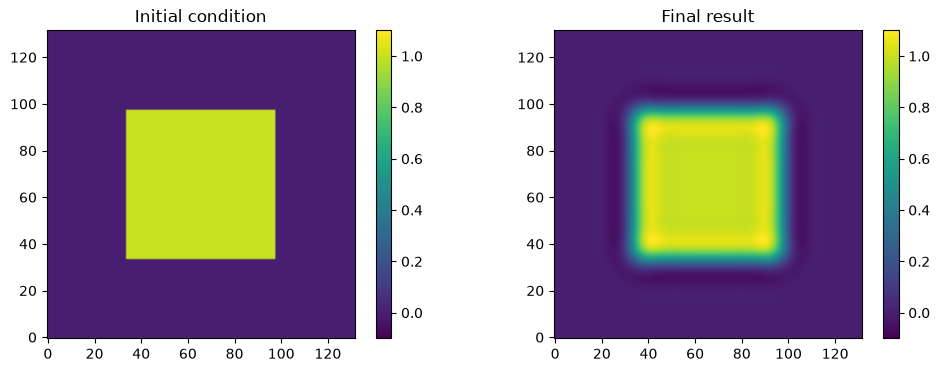

In [7]:
validate_results()

## Parallelization of the K-Loop
Let's use `perf_wrap.sh` to generate a performance report for the base version. This will be useful to guide our parallelization approach.

In [8]:
%%bash
srun -n 1 -c 72 ./perf_wrap.sh ./stencil2d-base.x --nx 128 --ny 128 --nz 64 --num_iter 1024

# ranks nx ny nz num_iter time
data = np.array( [ \
[    1,  128,  128,   64,    1024,  0.6261623E+00], \
] )


Take a look at the performance report in the file `perf/00000.txt`. Which functions consume most of the runtime? Which loops are likely to be the hot loops? These code regions should be the primary targets for parallelization with OpenMP.
<div class="alert alert-block alert-info">
<b>Now it's your turn...</b><br>
<b>1.</b> Make a copy of the source code and name it <tt>stencil2d-kparallel.F90</tt>. Compile it (see cell below) and run it (see cell after that). For the time being, the runtime should be the same as the base version. Insert the following block of code immediately at program start to print out the number of available threads.<br>
<b>Fortran</b><br>
<code>!$omp parallel
!$omp master
write(*,*) '#threads = ', omp_get_num_threads()
!$omp end master
!$omp end parallel
</code>
Compile and run your code again. How many threads do we have available? Does the number match the number of cores?
<br>
<b>2.</b> Now use OpenMP to parallelize the <tt>k</tt>-loop. Compile the code again and execute it. Quickly check that the results are still correct (using <tt>validate_results()</tt>, see below)<br>
<b>3.</b> What does the plot tell you? What might be the issue?<br>
<b>4.</b> Irrespective of the result, how fast is your code relative to the base version? What would you have expected?<br>
<b>5.</b> Generate a performance report and check what changed relative to the base version. What are the places that consume most of the runtime now?<br>
<b>6.</b> Rerun for <tt>nz</tt>=1, 24, 25, 48, 64, 480 and inspect the performance profiling report for each of these settings. Look at how the relative distribution of runtime changes. Can you guess what is happening? Why is <tt>nz</tt>=64 not an ideal setting?<br>
</div>

In [9]:
%%bash
make VERSION=kparallel-broken

mpif90 -ffree-line-length-none  -g1 -O3 -fno-inline -fno-optimize-sibling-calls -fno-omit-frame-pointer -march=native -funroll-loops -fopenmp -flto -fno-math-errno -c stencil2d-kparallel-broken.F90
mpif90 -ffree-line-length-none  -g1 -O3 -fno-inline -fno-optimize-sibling-calls -fno-omit-frame-pointer -march=native -funroll-loops -fopenmp -flto -fno-math-errno m_utils.o stencil2d-kparallel-broken.o -o stencil2d-kparallel-broken.x
cp stencil2d-kparallel-broken.x stencil2d.x


In [10]:
%%bash
srun -n 1 -c 72 ./stencil2d-kparallel-broken.x --nx 128 --ny 128 --nz 64 --num_iter 1024

 #threads =           72
# ranks nx ny nz num_iter time
data = np.array( [ \
[    1,  128,  128,   64,    1024,  0.1401977E+00], \
] )


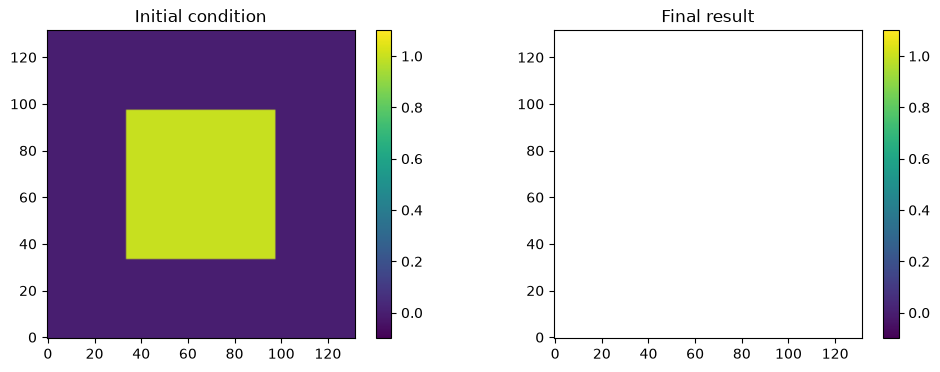

In [11]:
validate_results()

In [12]:
%%bash
srun -n 1 -c 72 ./perf_wrap.sh ./stencil2d-kparallel-broken.x --nx 128 --ny 128 --nz 64 --num_iter 1024

 #threads =           72
# ranks nx ny nz num_iter time
data = np.array( [ \
[    1,  128,  128,   64,    1024,  0.1634027E+00], \
] )


<b>ANSWERS</b><p>

3. Result looks broken. The problem is that the temporary variable is shared across the loop.<p>

![wrong.png](wrong.png)

 

## Variable Scoping

Inside a parallel region, variables can be either *shared* (all threads see the same copy) or *private* (each thread has its own copy). For now, we have not explicitly declared the scope of variables that are being used in the parallel region. If nothing is specified, the compiler assumes by default that all variables are shared. This is dangerous and can lead to very ugly errors. This is the error you've encountered above.

Some guidelines you can follow to decide the scope of variables are the following:
- Loop indices are private.
- Variables that are used (read or written) solely inside the parallel region are private.
- Variables that are only being read inside the parallel region are shared.

The <code>default(none)</code> clause is a useful safety mechanism: it disables OpenMP's implicit default scoping and forces you to explicitly classify every variable used inside the parallel region. This is slightly more verbose, but it prevents accidental sharing or privatization from going unnoticed.

<div class="alert alert-block alert-info">
<b>Now it's your turn...</b><br>
<b>7.</b> In order to avoid the default behavior, append the <code>default(none)</code> clause on the line with the <code>!$omp parallel do</code>. Recompile (see below). The compiler will now complain that the scope of several variables has not explicitly been specified. For each of these variables, you have to decide whether they are <code>private(var)</code> or <code>shared(var)</code>.<br>
<b>8.</b> Once your code compiles, run it and validate that the results still look correct.<br>
<b>9.</b> Move a single variable (e.g. <tt>nx</tt>) from shared to private, recompile, run and visualize the results. Do you understand what happened?<br>
<b>10.</b> Once you are sure that the variable scoping is correct, run one final time and compare the runtime against the previous version and the baseline. Do you understand why we are faster?<br>
</div>

In [13]:
%%bash
make VERSION=kparallel

mpif90 -ffree-line-length-none  -g1 -O3 -fno-inline -fno-optimize-sibling-calls -fno-omit-frame-pointer -march=native -funroll-loops -fopenmp -flto -fno-math-errno -c stencil2d-kparallel.F90
mpif90 -ffree-line-length-none  -g1 -O3 -fno-inline -fno-optimize-sibling-calls -fno-omit-frame-pointer -march=native -funroll-loops -fopenmp -flto -fno-math-errno m_utils.o stencil2d-kparallel.o -o stencil2d-kparallel.x
cp stencil2d-kparallel.x stencil2d.x


In [14]:
%%bash
srun -n 1 -c 72 ./stencil2d-kparallel.x --nx 128 --ny 128 --nz 64 --num_iter 1024

 #threads =           72
# ranks nx ny nz num_iter time
data = np.array( [ \
[    1,  128,  128,   64,    1024,  0.1413997E+00], \
] )


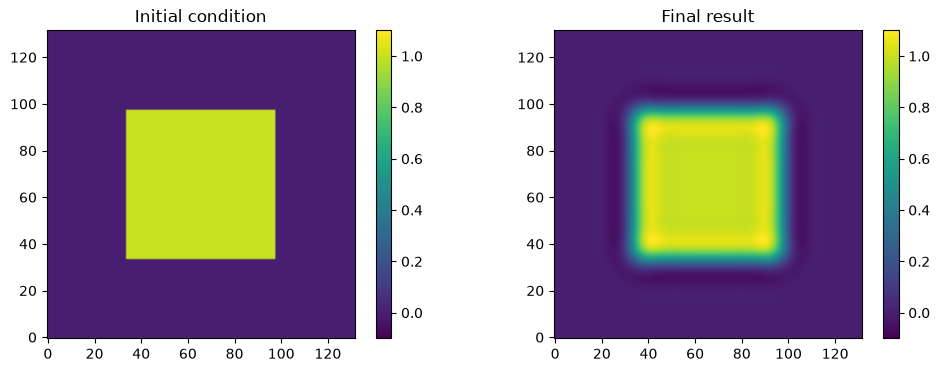

In [15]:
validate_results()

In [16]:
%%bash
srun -n 1 -c 72 ./perf_wrap.sh ./stencil2d-kparallel.x --nx 128 --ny 128 --nz 64 --num_iter 1024

 #threads =           72
# ranks nx ny nz num_iter time
data = np.array( [ \
[    1,  128,  128,   64,    1024,  0.1666151E+00], \
] )


<b>ANSWERS</b><p>

9. The GNU compiler does not complain and happily compiles your program if one variable is moved to private. This is clearly an error, since the thread-private instance of <tt>nx</tt> is accessed (read) before it has been defined (written). Other compilers (such as the Cray compiler) would warn you about this (see image below).

![broken.png](broken.png)

10. Now we are at 0.1636991 s, compared to sequential 0.6328564 s and wrong version 0.1656335 s. Performance and speedup do not tell us anything about correctness.

## Parallelization of the J-Loop
<div class="alert alert-block alert-info">
<b>Now it's your turn...</b><br>
<b>11.</b> Make a copy of the <tt>stencil2d-kparallel.F90</tt> program and name it <tt>stencil2d-jparallel.F90</tt>. This time use OpenMP to parallelize the <tt>j</tt>-loop. Make sure to remove the <tt>k</tt>-loop parallelization. Compile it and run it. How fast is your code? What would you have expected?<br>
<b>12.</b> Again generate a report. What changed? Can you use the report to explain your findings above?<br>
<b>13.</b> Run your code using just 1 thread (<code>OMP_NUM_THREADS=1</code>). How does the runtime compare against the base version? Run both versions of the code several times to make sure the result is reproducible. What could be the reason for the difference?<br>
<b>14.</b> Is it a good idea to try and parallelize the <tt>i</tt>-loop? Why?<br>
</div>

In [17]:
%%bash
make VERSION=jparallel

mpif90 -ffree-line-length-none  -g1 -O3 -fno-inline -fno-optimize-sibling-calls -fno-omit-frame-pointer -march=native -funroll-loops -fopenmp -flto -fno-math-errno -c stencil2d-jparallel.F90
mpif90 -ffree-line-length-none  -g1 -O3 -fno-inline -fno-optimize-sibling-calls -fno-omit-frame-pointer -march=native -funroll-loops -fopenmp -flto -fno-math-errno m_utils.o stencil2d-jparallel.o -o stencil2d-jparallel.x
cp stencil2d-jparallel.x stencil2d.x


In [18]:
%%bash
srun -n 1 -c 72 ./stencil2d-jparallel.x --nx 128 --ny 128 --nz 64 --num_iter 1024

 # threads =           72
# ranks nx ny nz num_iter time
data = np.array( [ \
[    1,  128,  128,   64,    1024,  0.1559918E+01], \
] )


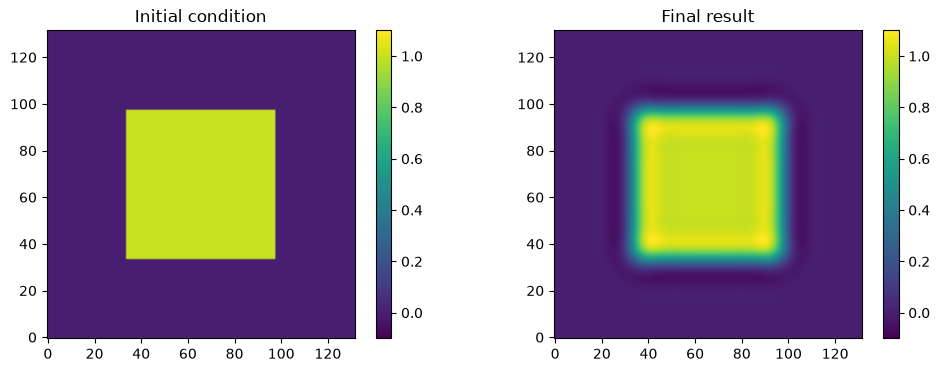

In [19]:
validate_results()

In [20]:
%%bash
srun -n 1 -c 72 ./perf_wrap.sh ./stencil2d-jparallel.x --nx 128 --ny 128 --nz 64 --num_iter 1024

 # threads =           72
# ranks nx ny nz num_iter time
data = np.array( [ \
[    1,  128,  128,   64,    1024,  0.1541019E+01], \
] )


In [21]:
%%bash
export OMP_NUM_THREADS=1
srun -n 1 -c 1 ./stencil2d-jparallel.x --nx 128 --ny 128 --nz 64 --num_iter 1024

 # threads =            1
# ranks nx ny nz num_iter time
data = np.array( [ \
[    1,  128,  128,   64,    1024,  0.7043004E+00], \
] )


### Performance analysis

Right now, the runtime increases to 1.621357 s, significantly slower than the sequential version (0.7015390 s).

If we look at the profile we see:

```
# Overhead  Command          Shared Object          Symbol                           
# ........  ...............  .....................  .................................
#
    56.63%  stencil2d-jpara  libgomp.so.1.0.0       [.] omp_get_num_procs
    38.93%  stencil2d-jpara  libgomp.so.1.0.0       [.] 0x0000000000045394
     1.53%  stencil2d-jpara  libgomp.so.1.0.0       [.] omp_fulfill_event
     1.37%  stencil2d-jpara  stencil2d-jparallel.x  [.] apply_diffusion.6._omp_fn.1
     1.05%  stencil2d-jpara  stencil2d-jparallel.x  [.] apply_diffusion.6._omp_fn.0
```

so we see a lot of parallelization overhead (visible by functions from libgomp, which is the OpenMP runtime library). This is due to the parallel region being opened inside the <tt>k</tt>-loop. The amount of work per parallel region is then too small, so OpenMP runtime overhead dominates.

## Setting the Number of Threads

We now know that we have 72 cores available on the CPU. We want to investigate what the best number of threads is. While it is possible to increase the number of threads beyond the number of cores, there is usually an optimum.

<div class="alert alert-block alert-info">
<b>Now it's your turn...</b><br>
<b>15.</b> Use the <tt>stencil2d-kparallel.F90</tt> version of the code you developed above and find the optimal number of threads.<br>
<b>16.</b> Do the same thing for the version where you have parallelized the j-loop.
</div>

In [22]:
%%bash
# The file should still be around, but if you need to recompile, here are the steps:
make VERSION=kparallel

make: 'stencil2d-kparallel.x' is up to date.


In [23]:
%%bash
# The file should still be around, but if you need to recompile, here are the steps:
make VERSION=jparallel

make: 'stencil2d-jparallel.x' is up to date.


In [24]:
%%bash
nthreads=1
echo "out = [None] * 73" > out.txt
for nthreads in `seq 1 72` ; do
export OMP_NUM_THREADS=$nthreads
  ncores=$nthreads
  if [ $nthreads -gt 72 ] ; then
    ncores=72
  fi
  srun -n 1 -c $ncores ./stencil2d-kparallel.x --nx 128 --ny 128 --nz 64 --num_iter 1024 | sed "s/data =/out[$nthreads] =/g" >> out.txt
done

In [25]:
exec(open("out.txt", "r").read())
labels = []
times = []
for i in range(len(out)):
    if i == 0:
        continue
    labels.append(i)
    times.append(out[i][:, 5].item())

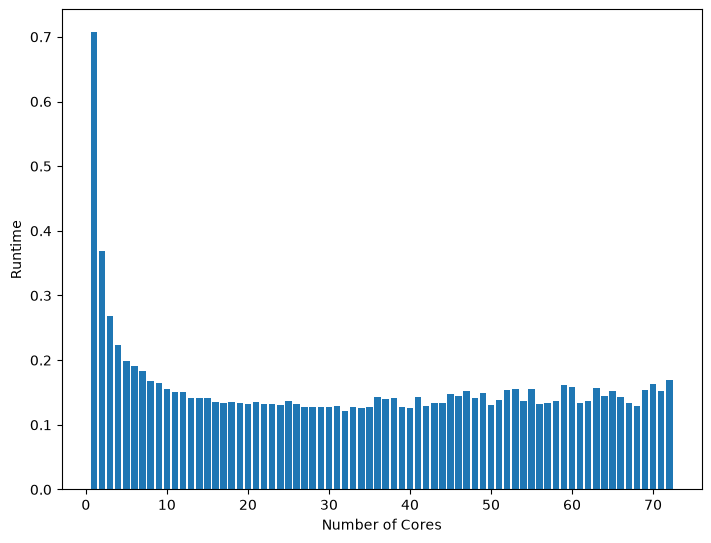

In [26]:
x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars
fig = plt.figure()
ax = fig.add_axes([0, 0, 1, 1])
ax.bar(labels, times)
ax.set_xlabel('Number of Cores')
ax.set_ylabel('Runtime')
plt.show()

In [27]:
%%bash
nthreads=1
echo "out_j = [None] * 73" > out_j.txt
for nthreads in `seq 1 72` ; do
export OMP_NUM_THREADS=$nthreads
  ncores=$nthreads
  if [ $nthreads -gt 72 ] ; then
    ncores=72
  fi
  srun -n 1 -c $ncores ./stencil2d-jparallel.x --nx 128 --ny 128 --nz 64 --num_iter 1024 | sed "s/data =/out_j[$nthreads] =/g" >> out_j.txt
done

In [28]:
exec(open("out_j.txt", "r").read())
labels = []
times = []
for i in range(len(out_j)):
    if i == 0:
        continue
    labels.append(i)
    times.append(out_j[i][:, 5].item())

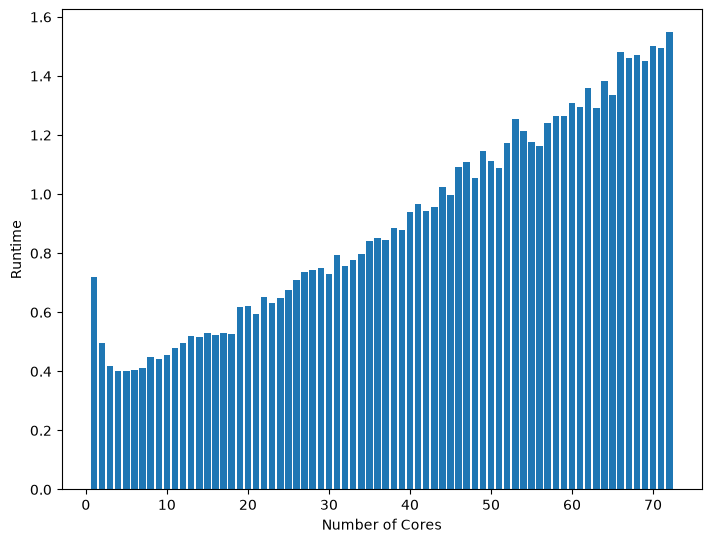

In [29]:
x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars
fig = plt.figure()
ax = fig.add_axes([0, 0, 1, 1])
ax.bar(labels, times)
ax.set_xlabel('Number of Cores')
ax.set_ylabel('Runtime')
plt.show()

<b>ANSWERS</b><p>

15./16. The k-loop version usually scales better because it opens one OpenMP region around the full vertical loop, so the runtime overhead is paid relatively rarely. The j-loop version opens OpenMP regions inside the k-loop, so each region contains less work and the repeated scheduling/startup overhead becomes visible. Even with one thread, the j-loop version can be slower than the sequential baseline because it still goes through the OpenMP runtime. Parallelizing the i-loop is not attractive in Fortran because i is the contiguous inner loop; splitting it creates very small chunks and can hurt vectorization and memory access efficiency.

<div class="alert alert-block alert-warning">
The concepts presented up to here are key to understanding how to optimize weather and climate codes. The next set of questions should deepen your understanding of OpenMP and shared memory parallelism in general. The following exercises can be considered a bonus if the time is too short.<br>
The questions are split into two sections: Deeper understanding of OpenMP and playing with minor optimizations in the stencil2d example. They can be solved in either order.
</div>

# Understanding OpenMP

## Diagnostics of our Field
The first task is to understand how to use critical sections, atomics and proper variable scoping to implement a function that calculates the maximum value present in the 3D field.

A <code>critical</code> section protects an arbitrary block of code so only one thread can execute it at a time. An <code>atomic</code> update is narrower: it protects a single supported memory update, usually with less overhead than a critical section.
<div class="alert alert-block alert-success">
<b>Now it's your turn...</b><br>
<b>B1.</b> Make a copy of the base source code and name it <tt>stencil2d-max.F90</tt>.<br>
Add a function that iterates over all elements of the field and reports the highest value found after every 100th iteration. Report the value to standard output with <code>write(*, *)</code>.<br>
<b>B2.</b> Make a copy of the maximum computing code and name it <tt>stencil2d-parallelmax.F90</tt>.<br>
In it, parallelize the diagnostics. Can you put this into an existing parallel region or does it need its own? Can you reproduce the same results?
</div>

In [30]:
%%bash
make VERSION=max

mpif90 -ffree-line-length-none  -g1 -O3 -fno-inline -fno-optimize-sibling-calls -fno-omit-frame-pointer -march=native -funroll-loops -fopenmp -flto -fno-math-errno -c stencil2d-max.F90
mpif90 -ffree-line-length-none  -g1 -O3 -fno-inline -fno-optimize-sibling-calls -fno-omit-frame-pointer -march=native -funroll-loops -fopenmp -flto -fno-math-errno m_utils.o stencil2d-max.o -o stencil2d-max.x
cp stencil2d-max.x stencil2d.x


In [31]:
%%bash
srun -n 1 -c 72 ./stencil2d-max.x --nx 128 --ny 128 --nz 64 --num_iter 410

# ranks nx ny nz num_iter time
data = np.array( [ \
 #   1.09911919    
 #   1.09988868    
 #   1.09759343    
 #   1.10005033    
[    1,  128,  128,   64,     410,  0.2801776E+00], \
] )


In [32]:
%%bash
make VERSION=parallelmax

mpif90 -ffree-line-length-none  -g1 -O3 -fno-inline -fno-optimize-sibling-calls -fno-omit-frame-pointer -march=native -funroll-loops -fopenmp -flto -fno-math-errno -c stencil2d-parallelmax.F90
mpif90 -ffree-line-length-none  -g1 -O3 -fno-inline -fno-optimize-sibling-calls -fno-omit-frame-pointer -march=native -funroll-loops -fopenmp -flto -fno-math-errno m_utils.o stencil2d-parallelmax.o -o stencil2d-parallelmax.x
cp stencil2d-parallelmax.x stencil2d.x


In [33]:
%%bash
srun -n 1 -c 72 ./stencil2d-parallelmax.x --nx 128 --ny 128 --nz 64 --num_iter 410

# ranks nx ny nz num_iter time
data = np.array( [ \
 #   1.09911919    
 #   1.09988868    
 #   1.09759343    
 #   1.10005033    
[    1,  128,  128,   64,     410,  0.2844113E+00], \
] )


## Manual Implementation of an OpenMP Worksharing Loop
There is a way to re-implement what a worksharing loop does with the directives `omp parallel`, `omp single` (or similar), and `omp task`. We let the scheduling happen automatically and do not worry about it for now. 
The second task is to write a simple loop that prints, for each iteration, the iteration number and the thread number executing it. A skeleton code is available in `forloop.F90`.
<div class="alert alert-block alert-success">
<b>Now it's your turn...</b><br>
<b>B3.</b> Insert the required OpenMP directives to make sure that more than one thread works on the various pieces of the code.
</div>

In [34]:
%%bash
gfortran -fopenmp -o forloop.x forloop.F90

In [35]:
%%bash
srun -n 1 -c 10 ./forloop.x 10

Thread 2 executed loop iteration 4
Thread 6 executed loop iteration 3
Thread 5 executed loop iteration 5
Thread 8 executed loop iteration 2
Thread 0 executed loop iteration 10
Thread 7 executed loop iteration 1
Thread 1 executed loop iteration 9
Thread 3 executed loop iteration 7
Thread 4 executed loop iteration 6
Thread 9 executed loop iteration 8


# Minor Optimizations of Stencil2D

## Fusing the Computation Loops

Currently we have the computation in two i-j loops. Since writing into a 2D field and reading it again can add memory overhead, we would ideally have the computation in just one loop.

There is a way to fuse the computational loops and keep the update in a separate loop.

The starting point is `stencil2d-fusion.F90`.

<div class="alert alert-block alert-success">
<b>Now it's your turn...</b><br>
<b>B4.</b> Implement the loop bounds and the computation.<br>
<b>B5.</b> Quickly check that the results are still correct (using <tt>validate_results()</tt>, see below)<br>
<b>B6.</b> Use any combination of techniques learned to parallelize this code.<br>
<b>B7.</b> Look at the performance in your ideal setting (parallelization with either j or k loop, optimal number of threads). How does it compare? How much speedup would you have expected?<br>
<b>B8.</b> By looking at the `perf_wrap.sh` report, can you explain the performance?
</div>

In [36]:
%%bash
make VERSION=fusion

mpif90 -ffree-line-length-none  -g1 -O3 -fno-inline -fno-optimize-sibling-calls -fno-omit-frame-pointer -march=native -funroll-loops -fopenmp -flto -fno-math-errno -c stencil2d-fusion.F90
mpif90 -ffree-line-length-none  -g1 -O3 -fno-inline -fno-optimize-sibling-calls -fno-omit-frame-pointer -march=native -funroll-loops -fopenmp -flto -fno-math-errno m_utils.o stencil2d-fusion.o -o stencil2d-fusion.x
cp stencil2d-fusion.x stencil2d.x


In [37]:
%%bash
srun -n 1 -c 72 ./stencil2d-fusion.x --nx 128 --ny 128 --nz 64 --num_iter 1024

# ranks nx ny nz num_iter time
data = np.array( [ \
[    1,  128,  128,   64,    1024,  0.8209852E+00], \
] )


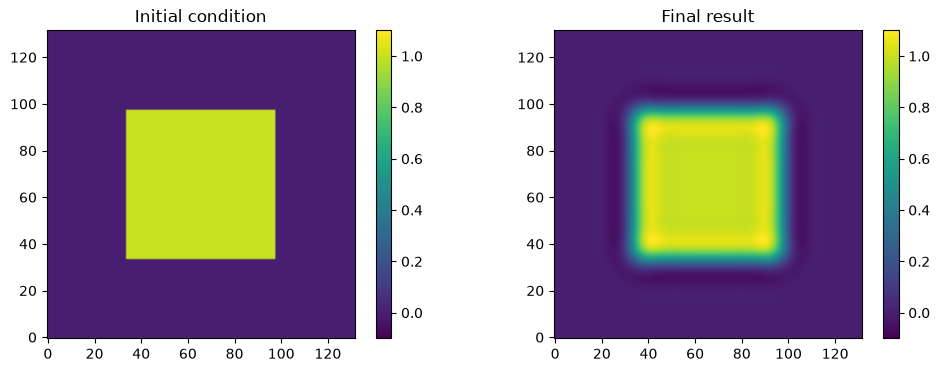

In [38]:
validate_results()

In [39]:
%%bash
srun -n 1 -c 72 ./perf_wrap.sh ./stencil2d-fusion.x --nx 128 --ny 128 --nz 64 --num_iter 1024

# ranks nx ny nz num_iter time
data = np.array( [ \
[    1,  128,  128,   64,    1024,  0.8183298E+00], \
] )


## Parallelizing the Halo Update

The halo updates are a set of small loops that are all independent. The amount of work in these loops is significantly smaller than the work in the main loop. We try to investigate how to parallelize them efficiently.
<div class="alert alert-block alert-success">
<b>Now it's your turn...</b><br>
<b>B9.</b> By looking at the `perf_wrap.sh` report of previous runs, can you explain why this was a bonus exercise? What is the expected performance gain of this parallelization? <br>
<b>B10.</b> Make a copy of the source code <tt>stencil2d-kparallel.F90</tt> and name it <tt>stencil2d-kparallel-halo.F90</tt>.<br>
<b>B11.</b> Implement a parallel version of the halo updates using what you learned before: which loop to parallelize, what number of threads to use, and how to scope the variables.<br>
<b>B12.</b> Quickly check that the results are still correct (using <tt>validate_results()</tt>, see below).<br>
<b>B13.</b> By looking at the performance report, can you discuss your predictions? Why were they, or were they not, matched?<br>    
</div>

In [40]:
%%bash
make VERSION=kparallel-halo

mpif90 -ffree-line-length-none  -g1 -O3 -fno-inline -fno-optimize-sibling-calls -fno-omit-frame-pointer -march=native -funroll-loops -fopenmp -flto -fno-math-errno -c stencil2d-kparallel-halo.F90
mpif90 -ffree-line-length-none  -g1 -O3 -fno-inline -fno-optimize-sibling-calls -fno-omit-frame-pointer -march=native -funroll-loops -fopenmp -flto -fno-math-errno m_utils.o stencil2d-kparallel-halo.o -o stencil2d-kparallel-halo.x
cp stencil2d-kparallel-halo.x stencil2d.x


In [41]:
%%bash
srun -n 1 -c 72 ./stencil2d-kparallel-halo.x --nx 128 --ny 128 --nz 64 --num_iter 1024

 #threads =           72
# ranks nx ny nz num_iter time
data = np.array( [ \
[    1,  128,  128,   64,    1024,  0.3163637E-01], \
] )


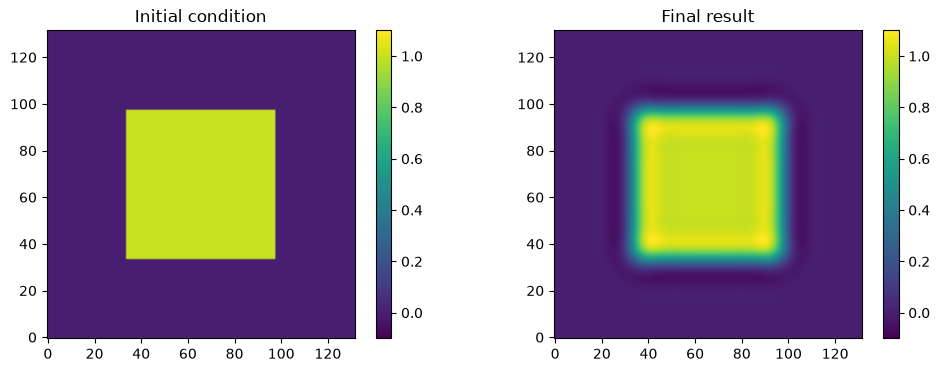

In [42]:
validate_results()

## Exploring the Ideal Schedule for Our Program
We know that in many programs, the loop schedule can have a significant impact on performance. Since weather and climate codes are usually well structured with similar workloads across iterations (excluding boundary layer computation in the vertical), finding the ideal schedule might only lead to small performance gains. We nevertheless try to understand how different schedules behave and what their performance looks like.

<div class="alert alert-block alert-success">
<b>Now it's your turn...</b><br>
<b>B14.</b> Modify your code <tt>stencil2d-jparallel.F90</tt> to test these three loop schedules: <br>
<code>schedule(static, 1)
schedule(static, chunk)   ! choose chunk roughly as ny / number_of_threads
schedule(dynamic, 1)
</code>
How does the performance compare? Can you explain what these schedules do?<br>
<b>B15.</b> What would happen if we did the same experiment on the kparallel version?<br>
<b>B16.</b> Can you think of codes where this is more impactful? Why?
</div>


In [43]:
%%bash
make VERSION=jparallel

make: 'stencil2d-jparallel.x' is up to date.


In [44]:
%%bash
srun -n 1 -c 72 ./stencil2d-jparallel.x --nx 128 --ny 128 --nz 64 --num_iter 1024

 # threads =           72
# ranks nx ny nz num_iter time
data = np.array( [ \
[    1,  128,  128,   64,    1024,  0.1586858E+01], \
] )


In [45]:
%%bash
make clean

rm -f -rf *~ *.o *.mod *.MOD *.i core.* *.out *.lst *.x *.x+orig *.x+[0-9]* *.dat *.report result_*.py report*.txt perf/* out*.txt
